In [84]:

import numpy as np
# from scipy.sparse import csr_matrix
import numpy as np
import matplotlib.pyplot as plt
import random
import time

In [85]:
def load_scp_column_format(filepath):
    with open(filepath, 'r') as f:
        data = list(map(int, f.read().split()))

    idx = 0

    # problem size
    m = data[idx]
    idx += 1
    n = data[idx]
    idx += 1

    costs = []
    columns = []  # columns[j] = set of rows covered by column j

    for _ in range(n):
        cost = data[idx]
        idx += 1

        k = data[idx]
        idx += 1

        rows = data[idx:idx + k]
        idx += k

        # convert to 0-based indexing
        rows = [r - 1 for r in rows]

        costs.append(cost)
        columns.append(set(rows))

    return m, n, costs, columns

In [86]:
def plot_column_sizes(columns):
    sizes = [len(c) for c in columns]

    plt.figure()
    plt.hist(sizes, bins=50)
    plt.title("Column Coverage Distribution")
    plt.xlabel("Number of rows covered")
    plt.ylabel("Frequency")
    plt.show()

def plot_sampled_matrix(A, max_rows=100, max_cols=200):
    rows = np.linspace(0, A.shape[0]-1, max_rows, dtype=int)
    cols = np.linspace(0, A.shape[1]-1, max_cols, dtype=int)

    sampled = A[rows][:, cols].toarray()

    plt.figure(figsize=(10, 5))
    plt.imshow(sampled, aspect='auto')
    plt.title("Sampled SCP Matrix (rows vs columns)")
    plt.xlabel("Columns (sampled)")
    plt.ylabel("Rows (sampled)")
    plt.colorbar()
    plt.show()


def plot_cost_vs_coverage(costs, columns):
    sizes = [len(c) for c in columns]

    plt.figure()
    plt.scatter(sizes, costs, alpha=0.5)
    plt.xlabel("Coverage (rows per column)")
    plt.ylabel("Cost")
    plt.title("Cost vs Coverage")
    plt.show()

In [87]:
folder="./rail/instances/"
m, n, costs, columns=load_scp_column_format(folder+'rail507')

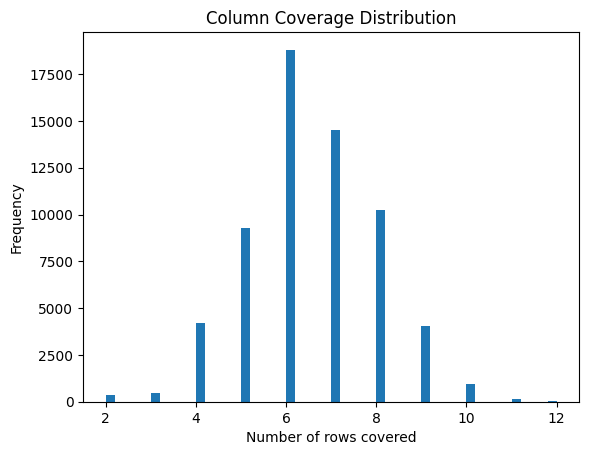

In [88]:
plot_column_sizes(columns)

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from SCSolution import SCSolution


def greedy(solution: SCSolution):
    while solution.uncovered:

        best_j = None
        best_score = float("inf")

        for j in range(solution.n):

            new_rows = solution.columns[j] & solution.uncovered

            if not new_rows:
                continue

            score = solution.costs[j] / len(new_rows)

            if score < best_score:
                best_score = score
                best_j = j

        if best_j is None:
            print("No feasible solution!")
            break

        solution.add_column(best_j)



In [90]:
def greedy_randomized(solution, alpha=3):
    # Use a local reference to solution.uncovered for speed
    while solution.uncovered:
        # Step 1: Pick a random uncovered row to focus on
        target_row = random.choice(solution.uncovered)
        
        # Step 2: Only look at columns that cover THIS row
        candidate_cols = solution.rows[target_row]
        
        scores = []
        uncovered_set = set(solution.uncovered) # for fast O(1) intersection check
        
        for j in candidate_cols:
            if solution.selected[j]:
                continue
                
            # Count how many NEW rows this column covers
            # Intersection with set is faster than looping
            new_coverage = len(solution.columns[j] & uncovered_set)
            
            if new_coverage > 0:
                # Score = cost / added_benefit
                score = solution.costs[j] / new_coverage
                scores.append((score, j))
        
        if not scores:
            break

        # Step 3: Restricted Candidate List
        scores.sort(key=lambda x: x[0])
        top_k = scores[:min(alpha, len(scores))]
        _, chosen_col = random.choice(top_k)

        solution.add_column(chosen_col)
        
    return solution

In [ ]:
def localSearchStep(solution)->SCSolution:
    # Track the best cost we've seen in this step
    # We work directly on the 'solution' object to avoid copies
    improved = False

    # 1. Exhaustive 1-remove with Undo
    selected_cols = [j for j in range(solution.n) if solution.selected[j]]
    random.shuffle(selected_cols)

    for j in selected_cols:
        old_cost = solution.total_cost
        
        # Action: Remove
        solution.remove_column(j)
        
        # Repair: (Note: greedy_randomized now modifies solution in place)
        # Store what was added so we can undo it if needed
        added_during_repair = []
        while solution.uncovered:
            target_row = random.choice(solution.uncovered)
            candidate_cols = solution.rows[target_row]
            
            # Simple greedy pick for local search (alpha=1 for speed)
            best_col = -1
            min_score = float('inf')
            uncovered_set = set(solution.uncovered)
            
            for c in candidate_cols:
                if solution.selected[c]: continue
                new_cov = len(solution.columns[c] & uncovered_set)
                if new_cov > 0:
                    score = solution.costs[c] / new_cov
                    if score < min_score:
                        min_score = score
                        best_col = c
            
            if best_col != -1:
                solution.add_column(best_col)
                added_during_repair.append(best_col)
            else: break
        
        solution.remove_redundant_columns()

        # Evaluation
        if solution.total_cost < old_cost:
            # Improvement found! Keep changes and update selected_cols for next loop
            improved = True
            return solution # First improvement strategy is often faster for SCP
        else:
            # Undo everything
            for added in added_during_repair:
                solution.remove_column(added)
            solution.add_column(j)

    return solution
def localSearch(solution):
    improved = True
    while improved:
        improved = False
        selected = [j for j in range(solution.n) if solution.selected[j]]
        random.shuffle(selected) # Critical: search different neighborhoods
        for j in random.sample(selected, min(len(selected),150)):
            # Try removing column j
            old_cost = solution.total_cost
            solution.remove_column(j)
            
            # Fast Repair: alpha=1 (pure greedy)
            # We don't want randomness here; we want the best local fix
            added = []
            while solution.uncovered:
                target_row = random.choice(solution.uncovered)
                # Find best col for THIS row only
                best_c = -1
                best_score = float('inf')
                for c in solution.rows[target_row]:
                    if solution.selected[c]: continue
                    # Quick score check
                    score = solution.costs[c] / len(solution.columns[c] & set(solution.uncovered))
                    if score < best_score:
                        best_score = score
                        best_c = c
                if best_c != -1:
                    solution.add_column(best_c)
                    added.append(best_c)
                else: break
            
            solution.remove_redundant_columns()
            
            if solution.total_cost < old_cost:
                improved = True
                break # First Improvement: exit the 'for' loop and start again
            else:
                # Undo
                for a in added: solution.remove_column(a)
                solution.add_column(j)
    return solution

In [117]:
# def perturb(solution, k=3):
#     candidate = solution.copy()

#     selected = [j for j in range(solution.n) if solution.selected[j]]

#     remove_set = random.sample(selected, min(k, len(selected)))

#     for j in remove_set:
#         candidate.remove_column(j)

#     return candidate
def ILS(initial_solution, iterations=75):
    best_ever = initial_solution.copy()
    current = initial_solution.copy() # Start from a fresh copy
    k = 5
    
    for _ in range(iterations):
        # t0=time.perf_counter()
        # Always perturb the best found so far to stay in the elite zone
        # OR keep current and only reset if k gets too high
        temp_sol = best_ever.copy() 
        
        # 1. Perturb
        selected = [j for j in range(temp_sol.n) if temp_sol.selected[j]]
        k_capped = min(k, len(selected))
        removed = random.sample(selected, k_capped)
        for j in removed:
            temp_sol.remove_column(j)
        
        # 2. Repair & Local Search
        temp_sol = greedy_randomized(temp_sol, alpha=2)
        temp_sol.remove_redundant_columns()
        # t2=time.perf_counter()
        temp_sol = localSearch(temp_sol)
        # t3=time.perf_counter()
        # print(f"local search step time {t3-t2}")
        # 3. Acceptance
        if temp_sol.total_cost < best_ever.total_cost:
            best_ever = temp_sol.copy()
            k = 5 # Reset intensity
            print(f"New Global Best: {best_ever.total_cost}")
        else:
            k += 1 # Slightly increase intensity
            if k > 20: k = 5 # Reset search back to base
        # t1=time.perf_counter()
        # print(f"iteration {_} time {t1-t0}")
            
    return best_ever

In [113]:
from SCSolution import SCSolution

folder="./rail/instances/"
m, n, costs, columns=load_scp_column_format(folder+'rail507')
#create rows data structure 
rows = [set() for row in range(m)]
for j, col in enumerate(columns):
    for i in col:
        rows[i].add(j)
sol=SCSolution(m, n, costs, columns, rows)
# ILS(m, n, costs, columns, rows)
# greedy(sol)

# print("Solution size:",sum(sol.selected))
# print("Total cost:", sol.total_cost)
# sol.remove_redundant_columns()

# print("Solution size:", sum(sol.selected))
# print("Total cost:", sol.total_cost)

# localSearch(sol)

In [120]:
def GRASP(m, n, costs, columns, rows, iterations=50)->SCSolution:
    best_overall = None
    
    for it in range(iterations):
        if best_overall is None or random.random() < 0.2:
            # 20% of the time, or if first run, start fresh
            sol = SCSolution(m, n, costs, columns, rows)
            t0=time.perf_counter()
            sol = greedy_randomized(sol, alpha=5)
            t1=time.perf_counter()
            print(f"greedy time {t1-t0}")
        else:
            # 80% of the time, "shatter" the best solution and repair it
            sol = best_overall.copy()
            # Remove 30% of its columns to force a new configuration
            selected = [j for j in range(sol.n) if sol.selected[j]]
            to_remove = random.sample(selected, int(len(selected) * 0.3))
            for j in to_remove:
                sol.remove_column(j)
            sol = greedy_randomized(sol, alpha=2)
            
        sol.remove_redundant_columns()
        sol = ILS(sol, iterations=50) # Give ILS more breathing room
        
        if best_overall is None or sol.total_cost < best_overall.total_cost:
            best_overall = sol.copy()
            print(f"--- NEW RECORD: {best_overall.total_cost} ---")

In [121]:
len(rows)

507

In [122]:
n

63009

In [123]:

res=GRASP(m, n, costs, columns, rows, iterations=50)
print(f" best {res}, cost: {res.total_cost}")

greedy time 0.03787990001728758
New Global Best: 222
New Global Best: 221
New Global Best: 220
New Global Best: 217
New Global Best: 215
New Global Best: 214
New Global Best: 213
New Global Best: 212
New Global Best: 211
--- NEW RECORD: 211 ---
greedy time 0.02896409999812022
New Global Best: 223
New Global Best: 220
New Global Best: 219
New Global Best: 217
New Global Best: 216
New Global Best: 215
New Global Best: 213
New Global Best: 212
New Global Best: 209
New Global Best: 208
New Global Best: 206
--- NEW RECORD: 206 ---
New Global Best: 214
New Global Best: 210
New Global Best: 209
New Global Best: 207
New Global Best: 206
New Global Best: 211
New Global Best: 208
New Global Best: 207
New Global Best: 205
New Global Best: 204
New Global Best: 202
--- NEW RECORD: 202 ---
New Global Best: 208
New Global Best: 207
New Global Best: 206
New Global Best: 205
New Global Best: 208
New Global Best: 206
New Global Best: 205
New Global Best: 204
New Global Best: 203
New Global Best: 202
New

KeyboardInterrupt: 

In [ ]:

sol=SCSolution(m, n, costs, columns, rows)
greedy_randomized(sol, alpha=1)
print("Solution size:",sum(sol.selected))
print("Total cost:", sol.total_cost)
sol.remove_redundant_columns()

print("Solution size:", sum(sol.selected))
print("Total cost:", sol.total_cost)

Solution size: 129
Total cost: 210
Solution size: 127
Total cost: 208
